# 04. Measurement Error

Measurement error is one of the quietest ways for a causal analysis to go wrong.

The data may contain exactly the rows we want. The treatment may look well-defined. The adjustment set may look defensible. But if key variables are measured badly, the analysis can estimate the wrong effect.

This notebook treats measurement as part of the causal design. We will separate four cases:

1. The outcome is noisy.
2. The treatment or exposure is misclassified.
3. A confounder is measured with error.
4. A proxy is used for a latent construct.

Each case has a different causal consequence. A noisy outcome is not the same problem as a noisy confounder. A noisy treatment is not the same problem as a noisy baseline covariate. A good analyst has to locate the measurement error before choosing a remedy.


## Learning Goals

By the end of this notebook, you should be able to:

- Distinguish measurement error in outcomes, treatments, confounders, and mediators.
- Explain why mean-zero outcome noise often reduces precision, while confounder noise can bias causal estimates.
- Use causal diagrams to represent true variables and measured proxies.
- Simulate attenuation from classical measurement error.
- Correct binary treatment misclassification when sensitivity and specificity are known or estimated from validation data.
- Use validation data, replicate measures, and SIMEX-style sensitivity analysis to reason about noisy confounders.
- Write an industry measurement-error plan for a causal project.


## 1. Setup

We will use the same core stack as the previous notebooks: pandas, numpy, statsmodels, seaborn, matplotlib, and Graphviz.


In [1]:
# Import the analysis, modeling, and plotting tools used throughout this notebook.
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.special import expit

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 90)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def regression_effect(model, term):
    """Compute regression effect for the measurement error example.
    
    Inputs:
    - `model`: fitted statistical or machine-learning model whose coefficients or predictions are being used.
    - `term`: coefficient name whose estimate and uncertainty should be extracted.
    Returns: an effect-estimate summary for the causal comparison in the section."""
    estimate = model.params[term]
    se = model.bse[term]
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
            "p_value": model.pvalues[term],
        }
    )


def mean_difference(df, outcome, treatment):
    """Compute mean difference for the measurement error example.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `outcome`: name of the observed outcome column whose causal contrast is being estimated.
    - `treatment`: name of the treatment-assignment column, usually coded as treated versus control.
    Returns: a treatment-control contrast with estimate and uncertainty fields."""
    treated = df.loc[df[treatment] == 1, outcome]
    control = df.loc[df[treatment] == 0, outcome]
    estimate = treated.mean() - control.mean()
    se = np.sqrt(treated.var(ddof=1) / treated.size + control.var(ddof=1) / control.size)
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
            "p_value": np.nan,
        }
    )


def plot_coef_table(table, title, xlabel, reference=0, figsize=(8.5, 4.5)):
    """Plot the coef table display.
    
    Inputs:
    - `table`: estimate table with columns such as estimate, standard error, and confidence limits.
    - `title`: plot or graph title displayed above the figure.
    - `xlabel`: x-axis label used in the estimate plot.
    - `reference`: reference value shown as a vertical line, often the true or benchmark effect.
    - `figsize`: Matplotlib figure size passed to the plotting function.
    Returns: a Matplotlib figure or axes object that visualizes the causal estimates."""
    plot_df = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        x=plot_df["estimate"],
        y=plot_df.index,
        xerr=[
            plot_df["estimate"] - plot_df["ci_lower"],
            plot_df["ci_upper"] - plot_df["estimate"],
        ],
        fmt="o",
        color="#2b8cbe",
        ecolor="#a6bddb",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    return fig, ax


### Dataset and Experiment Setup

This notebook uses simulated records where the true variable is known before measurement error is added. The unit is an individual, customer, case, or account depending on the section. The treatment, outcome, confounder, or mediator may be measured with error. Examples include noisy outcomes, misclassified treatment, proxy confounders, binary outcome misclassification, validation samples, calibration, and SIMEX-style sensitivity analysis.

The data is simulated because measurement error is most clearly taught when the true and recorded values can be compared. In real operational data, the true exposure log, true outcome, or true confounder is often exactly what we lack. The examples mimic realistic data problems such as delayed tracking, imperfect exposure recording, noisy survey measures, proxy risk scores, and label misclassification. The point is not that measurement error is a cleaning nuisance. It is part of the causal design because it can change bias, precision, and the meaning of the estimand.


## 2. Measurement Error as a Causal Object

Let $X$ denote the true variable and $X^\ast$ denote the measured variable.

A simple classical measurement-error model is:

$$
X^\ast = X + U
$$

where:

$$
E[U \mid X, A, Y] = 0
$$

This looks harmless, but its causal effect depends on what $X$ is.

- If $X$ is the outcome and the error is mean-zero, the treatment effect on the mean outcome can remain unbiased, but noisier.
- If $X$ is the treatment, treatment groups are mixed together.
- If $X$ is a confounder, adjustment is incomplete because $X^\ast$ does not fully block the backdoor path.
- If $X$ is a mediator or post-treatment variable, measurement error can distort decomposition or mechanism claims.


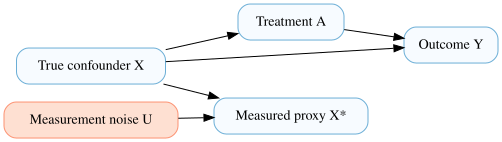

In [2]:
dot = Digraph("measurement_error_dag", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("X", "True confounder X")
dot.node("A", "Treatment A")
dot.node("Y", "Outcome Y")
dot.node("Xstar", "Measured proxy X*")
dot.node("U", "Measurement noise U", fillcolor="#fee0d2", color="#fc9272")

dot.edge("X", "A")
dot.edge("X", "Y")
dot.edge("A", "Y")
dot.edge("X", "Xstar")
dot.edge("U", "Xstar")

dot


The diagram shows a core causal problem: if $X$ confounds $A \rightarrow Y$, adjusting for $X^\ast$ is not the same as adjusting for $X$.

Kuroki and Pearl (2014) study this kind of measurement-bias problem using causal diagrams and discuss conditions under which proxy variables and external information can restore causal effects.


## 3. A Taxonomy for Causal Work

Before choosing a method, classify the measurement problem.


| measured_variable | example | typical_effect | common_response |
|---|---|---|---|
| Outcome Y | Revenue from an unreliable event pipeline | Mean-zero noise inflates variance; systematic or differential error biases effects. | Audit outcome definition; improve instrumentation; sensitivity analysis. |
| Treatment A | CRM says a customer received outreach, but logs disagree | Groups are mixed; effects are often attenuated or can change direction. | Use assignment logs; validation sample; misclassification correction. |
| Confounder X | Customer intent measured by a noisy score | Residual confounding remains after adjustment. | Collect better proxies; validation data; replicate measures; sensitivity analysis. |
| Mediator M | Engagement score used to explain why treatment worked | Direct/indirect effect decomposition becomes fragile. | Pre-specify measurement model; avoid overclaiming mechanisms. |


## 4. Simulation 1: Noisy Outcomes in a Randomized Experiment

Start with the cleanest setting: randomized treatment and a continuous outcome.

The true data-generating process is:

$$
Y = \alpha + \tau A + \epsilon
$$

where $A$ is randomized. Now suppose the measured outcome is:

$$
Y^\ast = Y + U
$$

If $E[U \mid A] = 0$, the difference in mean observed outcomes still targets $\tau$. If $E[U \mid A] \neq 0$, the measured outcome contains treatment-related measurement bias.


In [4]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4204)
n = 6000
true_tau = 2.0

df_outcome = pd.DataFrame(
    {
        "A": rng.binomial(1, 0.5, size=n),
        "baseline": rng.normal(0, 1, size=n),
    }
)

df_outcome["Y_true"] = (
    10
    + true_tau * df_outcome["A"]
    + 0.8 * df_outcome["baseline"]
    + rng.normal(0, 2.0, size=n)
)

df_outcome["Y_meanzero_noise"] = df_outcome["Y_true"] + rng.normal(0, 4.0, size=n)
df_outcome["Y_treatment_related_noise"] = (
    df_outcome["Y_true"]
    + rng.normal(0, 4.0, size=n)
    + 1.1 * df_outcome["A"]
)

outcome_estimates = pd.DataFrame(
    {
        "True outcome": mean_difference(df_outcome, "Y_true", "A"),
        "Mean-zero noisy outcome": mean_difference(df_outcome, "Y_meanzero_noise", "A"),
        "Treatment-related measurement bias": mean_difference(df_outcome, "Y_treatment_related_noise", "A"),
    }
).T

outcome_estimates


,estimate,std_error,ci_lower,ci_upper,p_value
True outcome,1.938,0.056,1.828,2.049,NaN
Mean-zero noisy outcome,2.002,0.118,1.771,2.233,NaN
Treatment-related measurement bias,2.961,0.116,2.733,3.189,NaN


At this point, ask what the result lets us defend. Noisy measures can attenuate, amplify, or redirect a causal estimate, so proxy quality is part of the design.

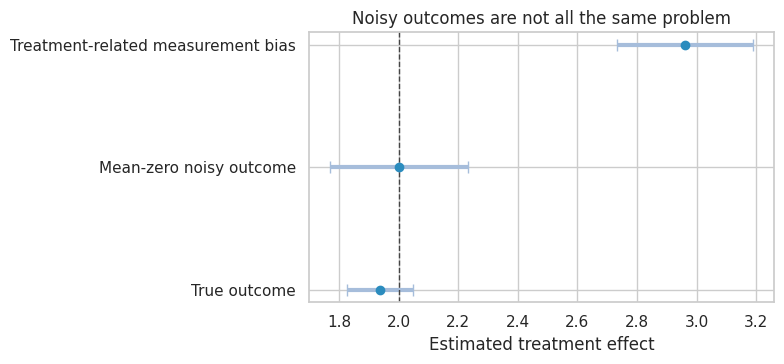

In [5]:
plot_coef_table(
    outcome_estimates,
    title="Noisy outcomes are not all the same problem",
    xlabel="Estimated treatment effect",
    reference=true_tau,
    figsize=(8, 3.8),
)
plt.show()


### Interpretation

The mean-zero noisy outcome remains centered near the true effect, but the interval is wider because the outcome has more variance.

The treatment-related measurement error moves the estimate. This is not a precision problem. It is a validity problem. In industry settings, this can happen when treatment affects tracking itself:

- A new checkout flow changes what events are fired.
- A sales outreach program changes how account managers enter notes.
- A model intervention changes the probability that users opt into telemetry.

The right response is not simply "collect more rows." More rows can make the biased estimate more precise.


## 5. Simulation 2: Treatment Misclassification

Now suppose the outcome is measured correctly, but treatment receipt is misclassified.

Let $A$ be true treatment and $A^\ast$ be recorded treatment. For a binary treatment:

$$
Sensitivity = P(A^\ast = 1 \mid A = 1)
$$

$$
Specificity = P(A^\ast = 0 \mid A = 0)
$$

If sensitivity and specificity are imperfect, the observed treated and control groups are mixtures of the true groups.


In [6]:
rng = np.random.default_rng(4205)
n = 7000
tau_treatment = 3.0
sens_A = 0.86
spec_A = 0.91

df_treat = pd.DataFrame({"A_true": rng.binomial(1, 0.48, size=n)})
df_treat["Y"] = 25 + tau_treatment * df_treat["A_true"] + rng.normal(0, 5, size=n)

observed_when_true_treated = rng.binomial(1, sens_A, size=n)
false_positive_when_true_control = rng.binomial(1, 1 - spec_A, size=n)
df_treat["A_observed"] = np.where(
    df_treat["A_true"] == 1,
    observed_when_true_treated,
    false_positive_when_true_control,
)

treatment_misclass_estimates = pd.DataFrame(
    {
        "Oracle: true treatment": mean_difference(df_treat, "Y", "A_true"),
        "Naive: recorded treatment": mean_difference(df_treat, "Y", "A_observed"),
    }
).T

treatment_misclass_estimates


,estimate,std_error,ci_lower,ci_upper,p_value
Oracle: true treatment,3.093,0.120,2.858,3.328,NaN
Naive: recorded treatment,2.389,0.123,2.148,2.629,NaN


The practical takeaway is simple. The estimate is only as defensible as the treatment, outcome, and covariate measurements behind it.

In [7]:
confusion = pd.crosstab(
    df_treat["A_true"],
    df_treat["A_observed"],
    normalize="index",
).rename_axis(index="True treatment", columns="Recorded treatment")

confusion


Recorded treatment,0,1
True treatment,,
0,0.908,0.092
1,0.148,0.852


The naive estimate is smaller because the recorded treatment groups contain contamination:

- Some truly treated units appear in the recorded-control group.
- Some truly untreated units appear in the recorded-treated group.

This is the treatment analogue of a blurred camera. The contrast between groups gets softened.


### Matrix Correction When Sensitivity and Specificity Are Known

If misclassification is independent of the outcome conditional on true treatment, we can express observed counts and observed outcome sums as mixtures of true counts and true outcome sums.

Let:

$$
Q =
\begin{bmatrix}
P(A^\ast=0 \mid A=0) & P(A^\ast=0 \mid A=1) \\
P(A^\ast=1 \mid A=0) & P(A^\ast=1 \mid A=1)
\end{bmatrix}
=
\begin{bmatrix}
specificity & 1 - sensitivity \\
1 - specificity & sensitivity
\end{bmatrix}
$$

Then:

$$
\begin{bmatrix}
N^\ast_0 \\
N^\ast_1
\end{bmatrix}
=
Q
\begin{bmatrix}
N_0 \\
N_1
\end{bmatrix}
$$

and the same mixing applies to outcome sums.


In [8]:
# Assemble the summary table used to interpret the causal comparison.
def correct_binary_treatment_misclassification(df, observed_treatment, outcome, sensitivity, specificity):
    """Correct a binary treatment-effect estimate for known sensitivity and specificity.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `observed_treatment`: recorded treatment column that may be misclassified relative to true treatment.
    - `outcome`: name of the observed outcome column whose causal contrast is being estimated.
    - `sensitivity`: probability that a truly positive treatment or outcome is recorded as positive.
    - `specificity`: probability that a truly negative treatment or outcome is recorded as negative.
    Returns: a pandas Series with corrected treatment counts, means, and effect estimate."""
    q = np.array(
        [
            [specificity, 1 - sensitivity],
            [1 - specificity, sensitivity],
        ]
    )
    counts_observed = (
        df.groupby(observed_treatment)
        .size()
        .reindex([0, 1], fill_value=0)
        .to_numpy(dtype=float)
    )
    sums_observed = (
        df.groupby(observed_treatment)[outcome]
        .sum()
        .reindex([0, 1], fill_value=0)
        .to_numpy(dtype=float)
    )
    
    counts_true_hat = np.linalg.solve(q, counts_observed)
    sums_true_hat = np.linalg.solve(q, sums_observed)
    means_true_hat = sums_true_hat / counts_true_hat
    return means_true_hat[1] - means_true_hat[0]


corrected_known = correct_binary_treatment_misclassification(
    df_treat,
    observed_treatment="A_observed",
    outcome="Y",
    sensitivity=sens_A,
    specificity=spec_A,
)

treatment_misclass_estimates.loc["Corrected: known sensitivity/specificity"] = {
    "estimate": corrected_known,
    "std_error": np.nan,
    "ci_lower": np.nan,
    "ci_upper": np.nan,
    "p_value": np.nan,
}

treatment_misclass_estimates


,estimate,std_error,ci_lower,ci_upper,p_value
Oracle: true treatment,3.093,0.120,2.858,3.328,NaN
Naive: recorded treatment,2.389,0.123,2.148,2.629,NaN
Corrected: known sensitivity/specificity,3.088,NaN,NaN,NaN,NaN


The result is useful when it changes what we audit, estimate, or decide. Measurement quality is not cosmetic. It changes the estimand and sometimes the conclusion.

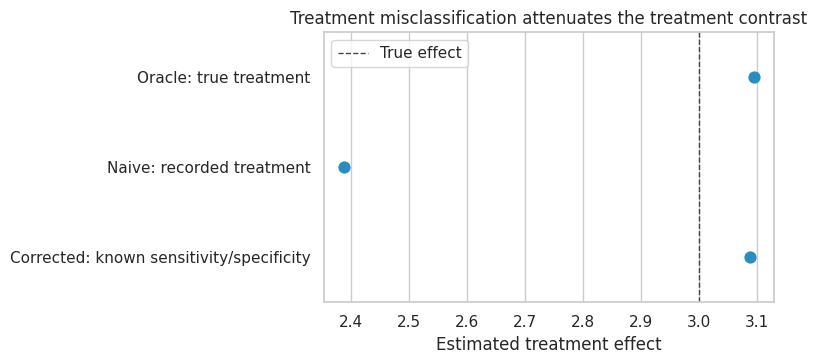

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.8))
display_df = treatment_misclass_estimates.reset_index(names="method")
sns.pointplot(data=display_df, y="method", x="estimate", join=False, ax=ax, color="#2b8cbe")
ax.axvline(tau_treatment, color="#444444", linestyle="--", linewidth=1, label="True effect")
ax.set_title("Treatment misclassification attenuates the treatment contrast")
ax.set_xlabel("Estimated treatment effect")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()


### Validation Data

In practice, we rarely know sensitivity and specificity exactly. We estimate them from a validation sample where the true treatment status is audited.

This validation sample might come from:

- manual CRM review,
- raw exposure logs,
- product instrumentation audit,
- medical chart review,
- customer-support transcript review.


In [10]:
validation = df_treat.sample(800, random_state=17)

sens_hat = validation.loc[validation["A_true"] == 1, "A_observed"].mean()
spec_hat = 1 - validation.loc[validation["A_true"] == 0, "A_observed"].mean()

corrected_validation = correct_binary_treatment_misclassification(
    df_treat,
    observed_treatment="A_observed",
    outcome="Y",
    sensitivity=sens_hat,
    specificity=spec_hat,
)

validation_summary = pd.DataFrame(
    {
        "quantity": ["Sensitivity", "Specificity", "Corrected effect"],
        "true_or_oracle": [sens_A, spec_A, tau_treatment],
        "estimated_from_validation": [sens_hat, spec_hat, corrected_validation],
    }
)

validation_summary


,quantity,true_or_oracle,estimated_from_validation
0,Sensitivity,0.860,0.856
1,Specificity,0.910,0.907
2,Corrected effect,3.000,3.117


The correction is only as credible as the validation design. If the validation sample overrepresents clean cases, active users, high-value customers, or recent records, its sensitivity and specificity may not represent the full analysis population.


## 6. Simulation 3: Noisy Confounders

Confounder measurement error is often more dangerous than outcome noise.

Suppose:

$$
X \rightarrow A
$$

and:

$$
X \rightarrow Y
$$

If we observe only $X^\ast$, adjustment for $X^\ast$ leaves residual confounding because units with the same measured score still differ in true $X$.


In [11]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4206)
n = 9000
true_tau_conf = 1.5

df_conf = pd.DataFrame({"X_true": rng.normal(0, 1, size=n)})
df_conf["A"] = rng.binomial(1, expit(-0.15 + 1.25 * df_conf["X_true"]), size=n)
df_conf["Y"] = (
    5
    + true_tau_conf * df_conf["A"]
    + 2.2 * df_conf["X_true"]
    + rng.normal(0, 1.5, size=n)
)

sigma_measure = 1.15
df_conf["X_claims_proxy"] = df_conf["X_true"] + rng.normal(0, sigma_measure, size=n)
df_conf["X_survey_proxy"] = df_conf["X_true"] + rng.normal(0, sigma_measure, size=n)
df_conf["X_proxy_average"] = (df_conf["X_claims_proxy"] + df_conf["X_survey_proxy"]) / 2

models_conf = {
    "Unadjusted": smf.ols("Y ~ A", data=df_conf).fit(),
    "Adjust for one noisy proxy": smf.ols("Y ~ A + X_claims_proxy", data=df_conf).fit(),
    "Adjust for two-proxy average": smf.ols("Y ~ A + X_proxy_average", data=df_conf).fit(),
    "Oracle: adjust for true X": smf.ols("Y ~ A + X_true", data=df_conf).fit(),
}

confounder_error_results = pd.DataFrame(
    {name: regression_effect(model, "A") for name, model in models_conf.items()}
).T

confounder_error_results


,estimate,std_error,ci_lower,ci_upper,p_value
Unadjusted,3.664,0.052,3.563,3.766,0.000
Adjust for one noisy proxy,2.838,0.047,2.745,2.931,0.000
Adjust for two-proxy average,2.471,0.045,2.383,2.560,0.000
Oracle: adjust for true X,1.487,0.036,1.416,1.557,0.000


Here the method has to be judged against the design and the evidence. Noisy measures can attenuate, amplify, or redirect a causal estimate, so proxy quality is part of the design.

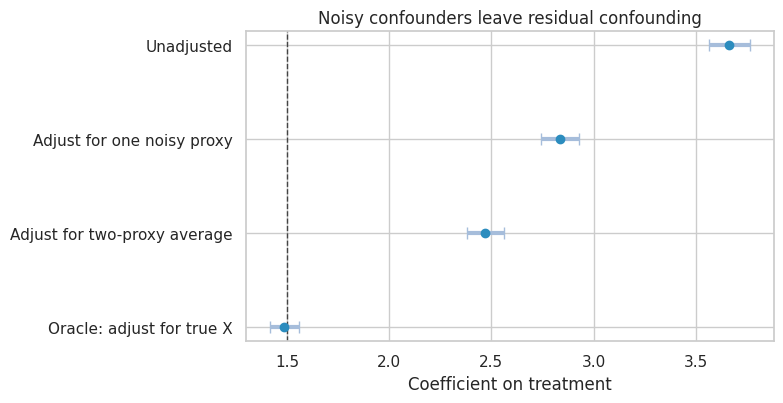

In [12]:
plot_coef_table(
    confounder_error_results,
    title="Noisy confounders leave residual confounding",
    xlabel="Coefficient on treatment",
    reference=true_tau_conf,
    figsize=(8, 4.2),
)
plt.show()


### Interpretation

The unadjusted estimate is biased because high-$X$ units are more likely to receive treatment and also have higher outcomes.

Adjusting for one noisy proxy helps but does not fully remove confounding. Averaging two independent proxies improves adjustment because the average is closer to the true latent confounder. The oracle model shows the estimate we would get if the true confounder were measured.

This is a common industry pattern:

- "Customer intent" is measured by recent clicks.
- "Account health" is measured by a risk score.
- "Disease severity" is measured by claims codes.
- "Manager quality" is measured by lagged team metrics.

These proxies can be useful, but they should not be mistaken for the construct itself.


## 7. Reliability Ratio and Attenuation

In a simple linear errors-in-variables problem:

$$
X^\ast = X + U
$$

with $U$ independent of $X$, the reliability ratio is:

$$
\lambda = \frac{Var(X)}{Var(X) + Var(U)}
$$

In a simple regression of $Y$ on $X^\ast$, the slope is attenuated toward zero by approximately $\lambda$.

In causal adjustment, the same intuition helps: lower reliability means less confounding is removed.


In [13]:
reliability_table = []
for sigma in [0.25, 0.5, 1.0, 1.5, 2.0]:
    tmp = df_conf.copy()
    tmp["X_star"] = tmp["X_true"] + rng.normal(0, sigma, size=tmp.shape[0])
    model = smf.ols("Y ~ A + X_star", data=tmp).fit()
    reliability = tmp["X_true"].var() / tmp["X_star"].var()
    reliability_table.append(
        {
            "measurement_sd": sigma,
            "empirical_reliability": reliability,
            "treatment_estimate": model.params["A"],
            "absolute_bias": abs(model.params["A"] - true_tau_conf),
        }
    )

reliability_table = pd.DataFrame(reliability_table)
reliability_table


,measurement_sd,empirical_reliability,treatment_estimate,absolute_bias
0,0.250,0.941,1.638,0.138
1,0.500,0.791,2.038,0.538
2,1.000,0.501,2.716,1.216
3,1.500,0.321,3.118,1.618
4,2.000,0.202,3.292,1.792


The point is to connect the number to the decision it supports. The estimate is only as defensible as the treatment, outcome, and covariate measurements behind it.

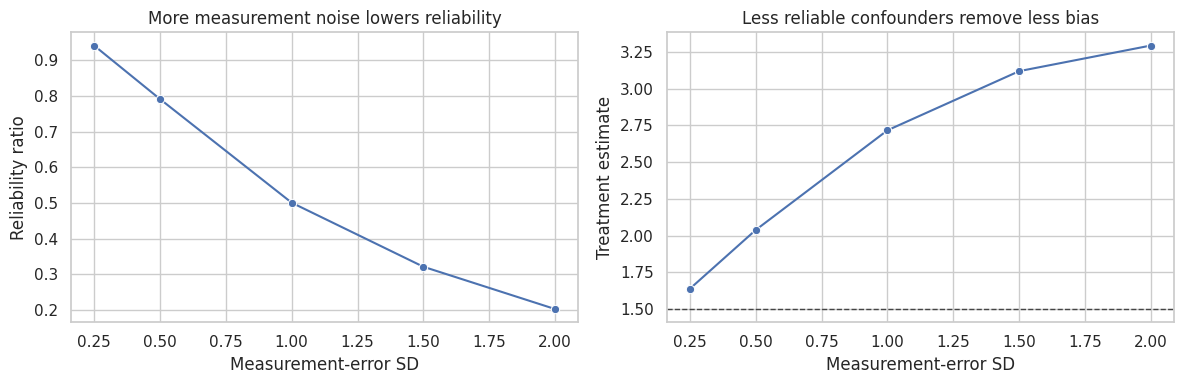

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(
    data=reliability_table,
    x="measurement_sd",
    y="empirical_reliability",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("More measurement noise lowers reliability")
axes[0].set_xlabel("Measurement-error SD")
axes[0].set_ylabel("Reliability ratio")

sns.lineplot(
    data=reliability_table,
    x="measurement_sd",
    y="treatment_estimate",
    marker="o",
    ax=axes[1],
)
axes[1].axhline(true_tau_conf, color="#444444", linestyle="--", linewidth=1)
axes[1].set_title("Less reliable confounders remove less bias")
axes[1].set_xlabel("Measurement-error SD")
axes[1].set_ylabel("Treatment estimate")

plt.tight_layout()
plt.show()


The right diagnostic is not only whether a proxy is predictive. It is whether it is reliable enough to block confounding paths for the causal question.

noisy measures can attenuate, amplify, or redirect causal estimates. The quality of a proxy is part of the design, not a cosmetic detail.

## 8. Validation Data and Calibration

Validation data means that for some units we observe both:

$$
X^\ast
$$

and:

$$
X
$$

That lets us learn how the proxy relates to the truth. Validation data can be internal or external:

- internal audit sample,
- duplicate survey,
- chart review,
- lab validation,
- high-quality data vendor sample,
- historical period with both old and new measurement systems.

Here we fit a calibration model for the true confounder using two proxies in a validation subset.


In [15]:
validation_conf = df_conf.sample(900, random_state=31).copy()

calibration_model = smf.ols(
    "X_true ~ X_claims_proxy + X_survey_proxy",
    data=validation_conf,
).fit()

df_conf["X_calibrated"] = calibration_model.predict(df_conf)

calibrated_model = smf.ols("Y ~ A + X_calibrated", data=df_conf).fit()
both_proxy_model = smf.ols("Y ~ A + X_claims_proxy + X_survey_proxy", data=df_conf).fit()

validation_results = confounder_error_results.copy()
validation_results.loc["Validation-calibrated proxy"] = regression_effect(calibrated_model, "A")
validation_results.loc["Adjust for both proxies directly"] = regression_effect(both_proxy_model, "A")

validation_results


,estimate,std_error,ci_lower,ci_upper,p_value
Unadjusted,3.664,0.052,3.563,3.766,0.000
Adjust for one noisy proxy,2.838,0.047,2.745,2.931,0.000
Adjust for two-proxy average,2.471,0.045,2.383,2.560,0.000
Oracle: adjust for true X,1.487,0.036,1.416,1.557,0.000
Validation-calibrated proxy,2.472,0.045,2.383,2.561,0.000
Adjust for both proxies directly,2.472,0.045,2.383,2.560,0.000


Here the example becomes operational. Measurement quality is not cosmetic. It changes the estimand and sometimes the conclusion.

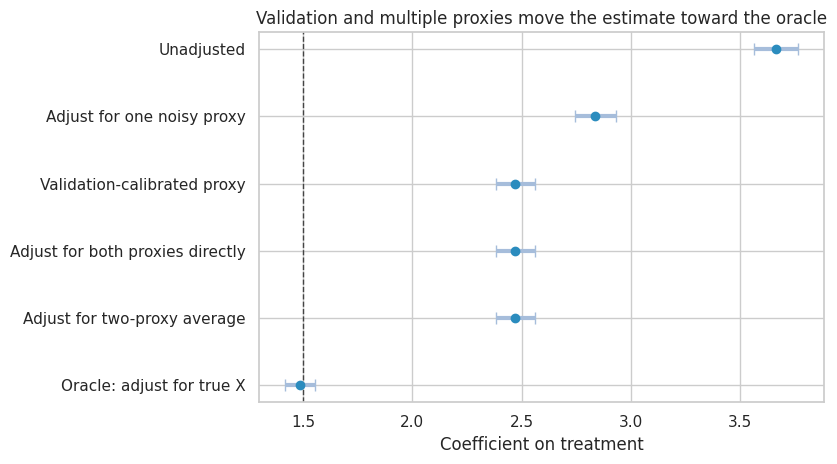

In [16]:
plot_coef_table(
    validation_results,
    title="Validation and multiple proxies move the estimate toward the oracle",
    xlabel="Coefficient on treatment",
    reference=true_tau_conf,
    figsize=(8.5, 4.8),
)
plt.show()


### Practical Warning

In this linear example, calibration and direct proxy adjustment are close because the calibration model is a linear combination of observed proxies. In more complex settings, validation data can support:

- nonlinear calibration,
- multiple imputation of the true confounder,
- likelihood-based measurement-error models,
- Bayesian measurement models,
- sensitivity analysis over plausible reliability levels.

The deeper point is not that one calibration recipe always solves the problem. The point is that validation information changes measurement error from an invisible assumption into an estimable design component.


## 9. SIMEX-Style Sensitivity Analysis

SIMEX stands for simulation-extrapolation. The idea is:

1. Add extra measurement error to the already noisy covariate.
2. Estimate the causal model at several extra-noise levels.
3. Extrapolate the trend back to a hypothetical no-error setting.

This correction depends on assumptions about the error process. It is useful as a transparent sensitivity analysis.


In [17]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4207)
lambda_grid = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
rows = []

for lam in lambda_grid:
    for rep in range(60):
        extra_noise = rng.normal(0, np.sqrt(lam) * sigma_measure, size=df_conf.shape[0])
        tmp = df_conf.assign(X_simex=df_conf["X_claims_proxy"] + extra_noise)
        est = smf.ols("Y ~ A + X_simex", data=tmp).fit().params["A"]
        rows.append({"lambda": lam, "rep": rep, "estimate": est})

simex_df = pd.DataFrame(rows)
simex_mean = simex_df.groupby("lambda", as_index=False)["estimate"].mean()

quadratic = np.polyfit(simex_mean["lambda"], simex_mean["estimate"], deg=2)
simex_extrapolated = np.polyval(quadratic, -1)

simex_summary = pd.DataFrame(
    {
        "method": [
            "Naive noisy-confounder adjustment",
            "SIMEX extrapolation to lambda = -1",
            "Oracle true-confounder adjustment",
        ],
        "estimate": [
            confounder_error_results.loc["Adjust for one noisy proxy", "estimate"],
            simex_extrapolated,
            confounder_error_results.loc["Oracle: adjust for true X", "estimate"],
        ],
    }
)

simex_mean, simex_summary


(   lambda  estimate
 0   0.000     2.838
 1   0.500     3.034
 2   1.000     3.152
 3   1.500     3.239
 4   2.000     3.298,
                                method  estimate
 0   Naive noisy-confounder adjustment     2.838
 1  SIMEX extrapolation to lambda = -1     2.356
 2   Oracle true-confounder adjustment     1.487)

This output should make the next modeling choice easier to defend. Noisy measures can attenuate, amplify, or redirect a causal estimate, so proxy quality is part of the design.

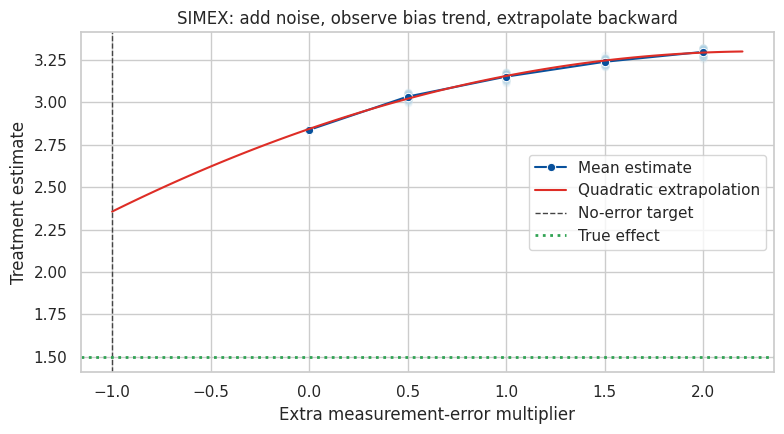

,method,estimate
0,Naive noisy-confounder adjustment,2.838
1,SIMEX extrapolation to lambda = -1,2.356
2,Oracle true-confounder adjustment,1.487


In [18]:
lambda_plot = np.linspace(-1, 2.2, 100)
pred_plot = np.polyval(quadratic, lambda_plot)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(data=simex_df, x="lambda", y="estimate", alpha=0.12, ax=ax, color="#9ecae1")
sns.lineplot(data=simex_mean, x="lambda", y="estimate", marker="o", ax=ax, color="#08519c", label="Mean estimate")
ax.plot(lambda_plot, pred_plot, color="#de2d26", label="Quadratic extrapolation")
ax.axvline(-1, color="#444444", linestyle="--", linewidth=1, label="No-error target")
ax.axhline(true_tau_conf, color="#31a354", linestyle=":", linewidth=2, label="True effect")
ax.set_title("SIMEX: add noise, observe bias trend, extrapolate backward")
ax.set_xlabel("Extra measurement-error multiplier")
ax.set_ylabel("Treatment estimate")
ax.legend()
plt.tight_layout()
plt.show()

simex_summary


### Interpretation

As extra noise is added to the confounder, the adjusted estimate drifts toward the unadjusted confounded estimate. Extrapolating backward gives a rough estimate of what might happen if the measurement error were removed.

This is best used as a sensitivity analysis, not as a replacement for good measurement.


## 10. Binary Outcome Misclassification

Continuous measurement error is not the only problem. Binary outcomes and binary labels can also be misclassified.

For a binary outcome:

$$
Y^\ast \in \{0,1\}
$$

with sensitivity and specificity:

$$
P(Y^\ast=1 \mid Y=1) = Se
$$

$$
P(Y^\ast=0 \mid Y=0) = Sp
$$

If $Se + Sp > 1$, an observed risk can be corrected by:

$$
\widehat{P}(Y=1) =
\frac{\widehat{P}(Y^\ast=1) + Sp - 1}{Se + Sp - 1}
$$


In [19]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
rng = np.random.default_rng(4208)
n = 8000
df_binary = pd.DataFrame({"A": rng.binomial(1, 0.5, size=n)})

p0 = 0.18
risk_difference_true = 0.08
df_binary["p_true"] = p0 + risk_difference_true * df_binary["A"]
df_binary["Y_true"] = rng.binomial(1, df_binary["p_true"])

sens_y = 0.82
spec_y = 0.93
draw = rng.uniform(size=n)
df_binary["Y_observed"] = np.where(
    df_binary["Y_true"] == 1,
    (draw < sens_y).astype(int),
    (draw > spec_y).astype(int),
)

def risk_difference(df, outcome):
    """Compute risk difference for the measurement error example.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `outcome`: name of the observed outcome column whose causal contrast is being estimated.
    Returns: a treatment-control contrast with estimate and uncertainty fields."""
    return (
        df.loc[df["A"] == 1, outcome].mean()
        - df.loc[df["A"] == 0, outcome].mean()
    )


def correct_binary_risk(p_observed, sensitivity, specificity):
    """Correct an observed binary risk for outcome misclassification.
    
    Inputs:
    - `p_observed`: observed positive risk or probability before misclassification correction.
    - `sensitivity`: probability that a truly positive treatment or outcome is recorded as positive.
    - `specificity`: probability that a truly negative treatment or outcome is recorded as negative.
    Returns: a scalar risk estimate adjusted for the supplied sensitivity and specificity."""
    return (p_observed + specificity - 1) / (sensitivity + specificity - 1)


observed_risks = df_binary.groupby("A")["Y_observed"].mean()
corrected_risks = observed_risks.apply(
    lambda p: correct_binary_risk(p, sens_y, spec_y)
)

binary_misclass_results = pd.DataFrame(
    {
        "method": [
            "Oracle: true outcome",
            "Naive: misclassified outcome",
            "Corrected with known Se/Sp",
        ],
        "risk_difference": [
            risk_difference(df_binary, "Y_true"),
            risk_difference(df_binary, "Y_observed"),
            corrected_risks.loc[1] - corrected_risks.loc[0],
        ],
    }
)

binary_misclass_results


,method,risk_difference
0,Oracle: true outcome,0.082
1,Naive: misclassified outcome,0.059
2,Corrected with known Se/Sp,0.079


The result is most useful when it shapes the next action. The estimate is only as defensible as the treatment, outcome, and covariate measurements behind it.

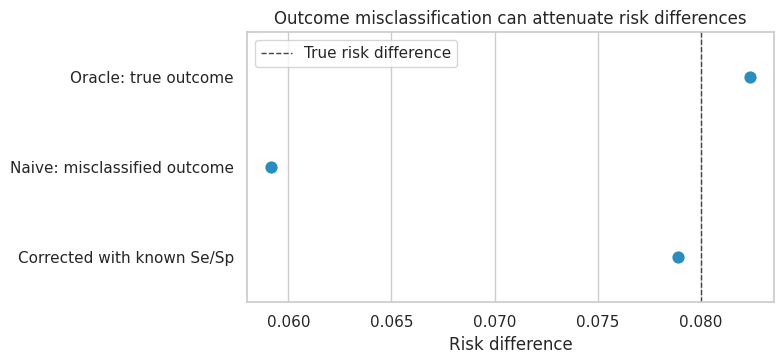

In [20]:
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.pointplot(data=binary_misclass_results, y="method", x="risk_difference", join=False, ax=ax, color="#2b8cbe")
ax.axvline(risk_difference_true, color="#444444", linestyle="--", linewidth=1, label="True risk difference")
ax.set_title("Outcome misclassification can attenuate risk differences")
ax.set_xlabel("Risk difference")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()


### Why This Matters for Industry

Binary outcomes are everywhere:

- churned or not,
- converted or not,
- fraud or not,
- retained or not,
- escalated support ticket or not.

The label is often a measurement process. If fraud labels depend on manual investigation, then the measured label reflects both fraud and investigation intensity. If churn labels depend on delayed billing data, the measured label reflects true churn and data latency.


## 11. Probabilistic Bias Analysis

Quantitative bias analysis makes measurement assumptions explicit. Sensitivity and specificity should be modeled with plausible distributions and propagated through the correction.

Lash, Fox, and Fink (2009) provide a broad epidemiologic treatment of quantitative bias analysis. The same idea is useful in business and platform settings.


In [21]:
rng = np.random.default_rng(4209)
bias_draws = 4000

sens_draw = rng.beta(82, 18, size=bias_draws)
spec_draw = rng.beta(93, 7, size=bias_draws)

p_obs_control = observed_risks.loc[0]
p_obs_treated = observed_risks.loc[1]

corrected_control = correct_binary_risk(p_obs_control, sens_draw, spec_draw)
corrected_treated = correct_binary_risk(p_obs_treated, sens_draw, spec_draw)
corrected_rd = corrected_treated - corrected_control

bias_analysis_summary = pd.Series(
    {
        "naive_observed_rd": risk_difference(df_binary, "Y_observed"),
        "median_corrected_rd": np.median(corrected_rd),
        "p05_corrected_rd": np.quantile(corrected_rd, 0.05),
        "p95_corrected_rd": np.quantile(corrected_rd, 0.95),
        "oracle_true_rd": risk_difference(df_binary, "Y_true"),
    }
)

bias_analysis_summary


naive_observed_rd     0.059
median_corrected_rd   0.079
p05_corrected_rd      0.072
p95_corrected_rd      0.088
oracle_true_rd        0.082
dtype: float64

This is a checkpoint for the design and the estimate together. Measurement quality is not cosmetic. It changes the estimand and sometimes the conclusion.

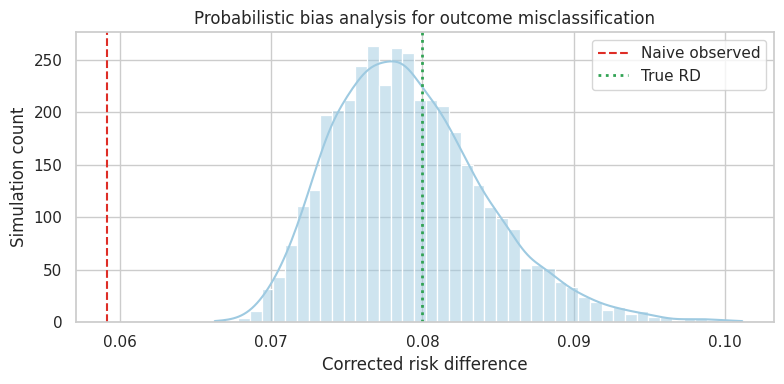

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(corrected_rd, bins=45, kde=True, color="#9ecae1", ax=ax)
ax.axvline(risk_difference(df_binary, "Y_observed"), color="#de2d26", linestyle="--", label="Naive observed")
ax.axvline(risk_difference_true, color="#31a354", linestyle=":", linewidth=2, label="True RD")
ax.set_title("Probabilistic bias analysis for outcome misclassification")
ax.set_xlabel("Corrected risk difference")
ax.set_ylabel("Simulation count")
ax.legend()
plt.tight_layout()
plt.show()


The result is no longer a single corrected estimate. It is a distribution over corrected estimates induced by uncertainty in measurement quality.

This is often the honest format for decision-making. It separates:

- random sampling uncertainty,
- uncertainty about the causal design,
- uncertainty about measurement validity.


## 12. Measurement Error in Mediators

Measurement error in mediators is especially easy to overinterpret.

Suppose:

$$
A \rightarrow M \rightarrow Y
$$

and we observe:

$$
M^\ast = M + U
$$

If we estimate mediation effects using $M^\ast$, the indirect effect can be attenuated, distorted, or made to look absent even when the underlying mechanism is strong.


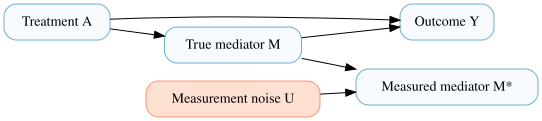

In [23]:
dot = Digraph("mediator_measurement", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("A", "Treatment A")
dot.node("M", "True mediator M")
dot.node("Y", "Outcome Y")
dot.node("Mstar", "Measured mediator M*")
dot.node("U", "Measurement noise U", fillcolor="#fee0d2", color="#fc9272")

dot.edge("A", "M")
dot.edge("M", "Y")
dot.edge("A", "Y")
dot.edge("M", "Mstar")
dot.edge("U", "Mstar")

dot


A useful professional habit is to downgrade mechanism claims when mediator measurement is weak.

It may be reasonable to say:

> The treatment improved revenue, and engagement increased after treatment.

It is stronger, and often less justified, to say:

> The treatment improved revenue because engagement increased.

The second statement requires a mediation design and a credible mediator measurement model.


## 13. Industry Measurement-Error Checklist

For each important causal variable, ask:


| question | example |
|---|---|
| What is the true construct? | Customer intent, actual exposure, real churn, clinical severity |
| What is the measured field? | Click count, logged campaign flag, billing cancel flag, claims score |
| Who or what records it? | Frontend event, backend service, salesperson, manual reviewer |
| Can treatment affect measurement? | New UI changes event firing; outreach changes CRM entry behavior |
| Is there validation data? | Audit sample, duplicate source, raw logs, gold-standard panel |
| Is error likely differential? | Measurement quality differs by treatment, segment, geography, or time |
| What sensitivity analysis is decision-relevant? | How bad must sensitivity/specificity be to change the launch decision? |


## 14. Decision Memo Example

A concise measurement-error memo for an industry causal project might look like this:


In [25]:
memo = '''
### Measurement-Error Memo

**Decision context.** Estimate the effect of a retention intervention on 30-day renewal.

**Main risk.** The renewal outcome is based on billing events. A migration changed event timing during the experiment window, so outcome measurement may differ by treatment cohort.

**Variables at risk.**

- Treatment: assignment is reliable because it comes from experiment allocation logs.
- Outcome: renewal label may be delayed or misclassified.
- Confounders: pre-period customer health score is a proxy, not the construct itself.

**Primary analysis.**

- Use assignment logs for treatment.
- Define renewal from reconciled billing tables, with frontend events used only as supporting signals.
- Adjust for pre-treatment health score, contract value, tenure, and product usage.

**Validation plan.**

- Audit a random sample of accounts against finance records.
- Estimate sensitivity and specificity of the renewal label by treatment arm.
- Compare estimates using raw labels, reconciled labels, and bias-corrected labels.

**Sensitivity question.**

- Would the launch decision change if renewal sensitivity differed by 5 percentage points across arms?

**Reporting rule.**

- Report the causal estimate and a measurement-error sensitivity interval, not only the conventional confidence interval.
'''.strip()

display(Markdown(memo))


### Measurement-Error Memo

**Decision context.** Estimate the effect of a retention intervention on 30-day renewal.

**Main risk.** The renewal outcome is based on billing events. A migration changed event timing during the experiment window, so outcome measurement may differ by treatment cohort.

**Variables at risk.**

- Treatment: assignment is reliable because it comes from experiment allocation logs.
- Outcome: renewal label may be delayed or misclassified.
- Confounders: pre-period customer health score is a proxy, not the construct itself.

**Primary analysis.**

- Use assignment logs for treatment.
- Define renewal from reconciled billing tables, with frontend events used only as supporting signals.
- Adjust for pre-treatment health score, contract value, tenure, and product usage.

**Validation plan.**

- Audit a random sample of accounts against finance records.
- Estimate sensitivity and specificity of the renewal label by treatment arm.
- Compare estimates using raw labels, reconciled labels, and bias-corrected labels.

**Sensitivity question.**

- Would the launch decision change if renewal sensitivity differed by 5 percentage points across arms?

**Reporting rule.**

- Report the causal estimate and a measurement-error sensitivity interval, not only the conventional confidence interval.

## 15. Common Failure Modes

1. Treating a proxy as the true construct.
2. Adjusting for a noisy confounder and declaring confounding solved.
3. Ignoring treatment effects on measurement systems.
4. Using validation data from an unrepresentative subset.
5. Reporting narrow confidence intervals while hiding measurement uncertainty.
6. Correcting for misclassification with sensitivity and specificity values that are guesses, without sensitivity analysis.
7. Making mechanism claims from noisy mediator measurements.


## 16. Exercises

1. In the noisy outcome simulation, change the treatment-related measurement bias from $1.1$ to $-1.1$. What happens to the treatment effect?
2. In the treatment misclassification simulation, reduce sensitivity to $0.70$. How does the naive estimate change?
3. In the noisy confounder simulation, increase the measurement-error standard deviation to $2.0$. Compare one proxy, two proxies, and the oracle adjustment.
4. In the binary outcome misclassification section, use different sensitivity and specificity by treatment arm. Does nondifferential intuition still hold?
5. Design a validation sample for a recommender-system causal analysis where treatment exposure is logged imperfectly.
6. Pick one real business metric you use. Write down the true construct, the measured field, and three ways the measurement can fail.


## 17. Key Takeaways

- Measurement error is part of the causal design, not only a data-cleaning issue.
- Mean-zero outcome noise usually hurts precision; differential outcome error can bias effects.
- Treatment misclassification mixes treated and control groups.
- Noisy confounders leave residual confounding after adjustment.
- Validation data, replicate measures, and sensitivity analysis are often more credible than pretending measurement is perfect.
- Mechanism claims require especially careful mediator measurement.
- The professional standard is to state measurement assumptions in the same explicit way we state exchangeability, positivity, and consistency assumptions.


## References

Carroll, R. J., Ruppert, D., Stefanski, L. A., & Crainiceanu, C. M. (2006). *Measurement error in nonlinear models: A modern perspective* (2nd ed.). Chapman & Hall/CRC. https://doi.org/10.1201/9781420010138

Fuller, W. A. (1987). *Measurement error models*. Wiley. https://doi.org/10.1002/9780470316665

Greenland, S. (1980). The effect of misclassification in the presence of covariates. *American Journal of Epidemiology, 112*(4), 564-569. https://doi.org/10.1093/oxfordjournals.aje.a113025

Kuroki, M., & Pearl, J. (2014). Measurement bias and effect restoration in causal inference. *Biometrika, 101*(2), 423-437. https://doi.org/10.1093/biomet/ast066

Lash, T. L., Fox, M. P., & Fink, A. K. (2009). *Applying quantitative bias analysis to epidemiologic data*. Springer. https://doi.org/10.1007/978-0-387-87959-8
